# Capstone 3: NYC Taxi Data Wrangling & EDA

## Objective
The goal of this project is to clean and explore NYC taxi trip data in order to understand the key factors that influence trip duration. Through data wrangling and exploratory analysis, we aim to identify patterns related to trip distance, time of day, and passenger characteristics that may impact the length of a taxi ride.

## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
df = pd.read_csv('../data/yellow_tripdata_2015-01.csv', nrows=100000)

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30


## Initial Data Assessment

We begin by examining the structure and summary statistics of the dataset to understand data types, distributions, and potential issues.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               100000 non-null  int64  
 1   tpep_pickup_datetime   100000 non-null  object 
 2   tpep_dropoff_datetime  100000 non-null  object 
 3   passenger_count        100000 non-null  int64  
 4   trip_distance          100000 non-null  float64
 5   pickup_longitude       100000 non-null  float64
 6   pickup_latitude        100000 non-null  float64
 7   RateCodeID             100000 non-null  int64  
 8   store_and_fwd_flag     100000 non-null  object 
 9   dropoff_longitude      100000 non-null  float64
 10  dropoff_latitude       100000 non-null  float64
 11  payment_type           100000 non-null  int64  
 12  fare_amount            100000 non-null  float64
 13  extra                  100000 non-null  float64
 14  mta_tax                100000 non-nul

In [4]:
df.describe()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.516030,1.66818,2.766231,-72.575004,39.979964,1.036410,-72.617655,40.004596,1.38704,11.865925,0.320095,0.497570,1.544944,0.247435,0.284331,14.775254
std,0.499745,1.32375,3.438196,10.078630,5.553303,0.516534,9.925810,5.468119,0.49856,10.038756,0.373561,0.036798,2.286399,1.281223,0.066747,12.235517
min,1.000000,0.00000,0.000000,-80.592438,0.000000,1.000000,-74.393951,0.000000,1.00000,-138.900000,-1.000000,-0.500000,-58.090000,-5.330000,0.000000,-139.700000
25%,1.000000,1.00000,1.000000,-73.991592,40.736145,1.000000,-73.991150,40.734630,1.00000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.190000
50%,2.000000,1.00000,1.650000,-73.981461,40.753529,1.000000,-73.979805,40.753777,1.00000,9.000000,0.000000,0.500000,1.000000,0.000000,0.300000,11.160000
75%,2.000000,2.00000,2.990000,-73.966423,40.767785,1.000000,-73.962532,40.768926,2.00000,13.500000,0.500000,0.500000,2.080000,0.000000,0.300000,16.300000
max,2.000000,9.00000,181.400000,0.000000,41.105976,99.000000,0.000000,41.220047,4.00000,234.000000,7.000000,0.500000,100.000000,95.330000,0.300000,270.130000


In [5]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RateCodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

## Data Cleaning and Wrangling

The dataset was examined for data quality issues including incorrect data types and invalid values. The following steps were taken to prepare the data for analysis.

### Data Type Corrections

In [6]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

### Removing Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset.

### Handling Outliers

#### Creating Trip Duration (in minutes)

Trip duration was calculated using pickup and dropoff timestamps. 
Records with invalid durations (zero or negative values) and extreme outliers 
(trips longer than 5 hours) were removed to ensure a realistic dataset for analysis.

In [8]:
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [9]:
df['trip_duration'].describe()

count    100000.000000
mean         13.028574
std          33.270519
min           0.000000
25%           6.100000
50%           9.950000
75%          15.766667
max        1439.050000
Name: trip_duration, dtype: float64

In [10]:
df = df[
    (df['trip_duration'] > 0) &
    (df['trip_duration'] < 300)
]

In [11]:
df['trip_duration'].describe()

count    99838.000000
mean        12.291481
std          9.245727
min          0.016667
25%          6.116667
50%          9.966667
75%         15.766667
max        237.000000
Name: trip_duration, dtype: float64

#### Clean Invalid Values

In [12]:
df = df[
    (df['trip_duration'] > 0) &
    (df['trip_duration'] < 300) &
    (df['trip_distance'] > 0) &
    (df['passenger_count'] > 0)
]

## Feature Engineering

In [13]:
# Extract time-based features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

In [14]:
df[['pickup_hour', 'pickup_day']].head()

,pickup_hour,pickup_day
0,19,Thursday
1,20,Saturday
2,20,Saturday
3,20,Saturday
4,20,Saturday


## Exploratory Data Analysis

### Trip Duration Distribution

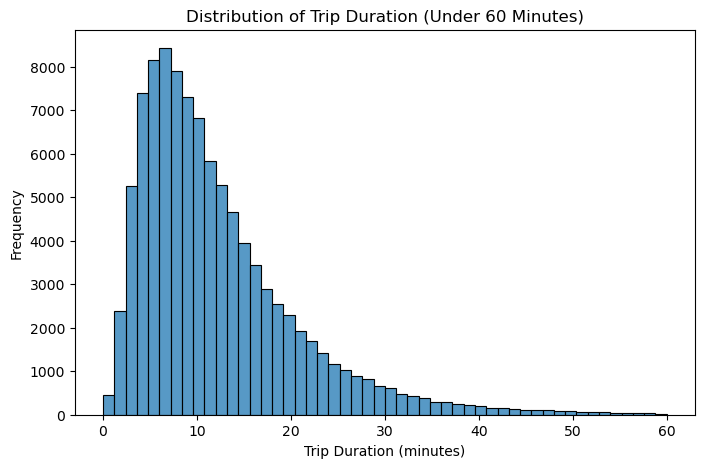

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['trip_duration'] < 60]['trip_duration'], bins=50)
plt.title('Distribution of Trip Duration (Under 60 Minutes)')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

The distribution of trip duration is right-skewed, with the majority of trips concentrated within a shorter time range. Most trips appear to last between approximately 5 and 20 minutes, with a peak around 10 minutes. Longer trips are less frequent, forming a long tail in the distribution.

### Trip Distance vs Trip Duration

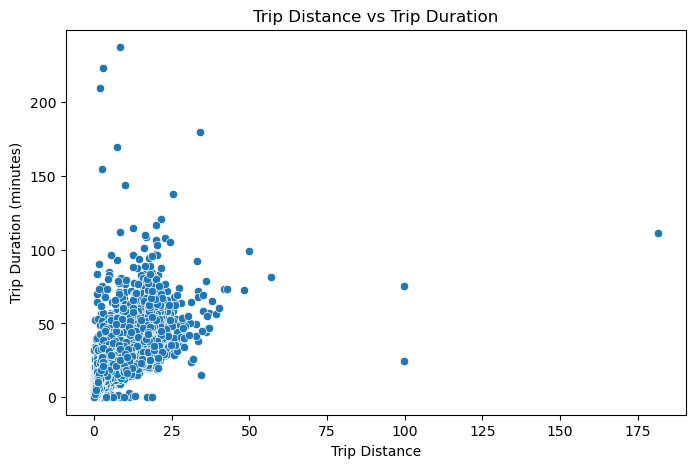

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='trip_distance', y='trip_duration', data=df)
plt.title('Trip Distance vs Trip Duration')
plt.xlabel('Trip Distance')
plt.ylabel('Trip Duration (minutes)')
plt.show()

There is a clear positive relationship between trip distance and trip duration, indicating that longer trips generally take more time. However, the relationship is not strictly linear, as there is significant variability in duration for similar distances. This suggests that additional factors, such as traffic conditions and time of day, may influence trip duration beyond distance alone.

### Trip Duration by Pickup Hour

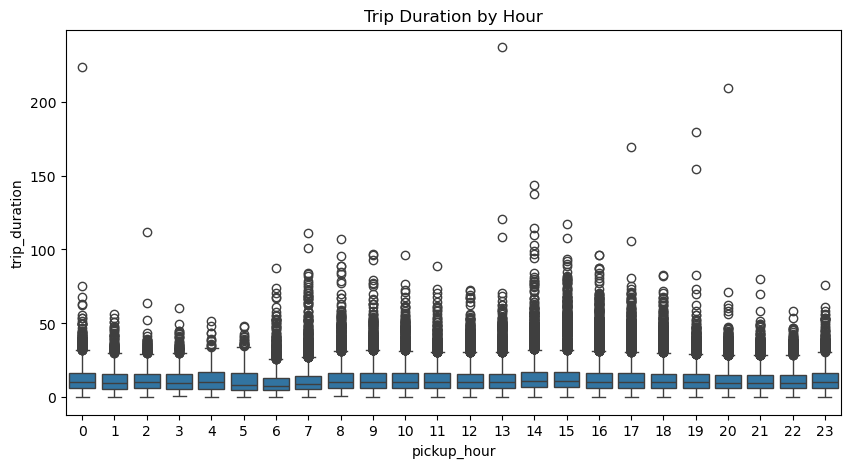

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(x='pickup_hour', y='trip_duration', data=df)
plt.title('Trip Duration by Hour')
plt.show()

Trip duration appears to increase slightly during typical commuting hours, particularly in the morning and late afternoon. This pattern suggests that traffic congestion during peak travel times may contribute to longer trip durations. However, the variation across hours is relatively moderate, indicating that time of day alone is not a dominant factor.

### Trip Duration by Day of Week

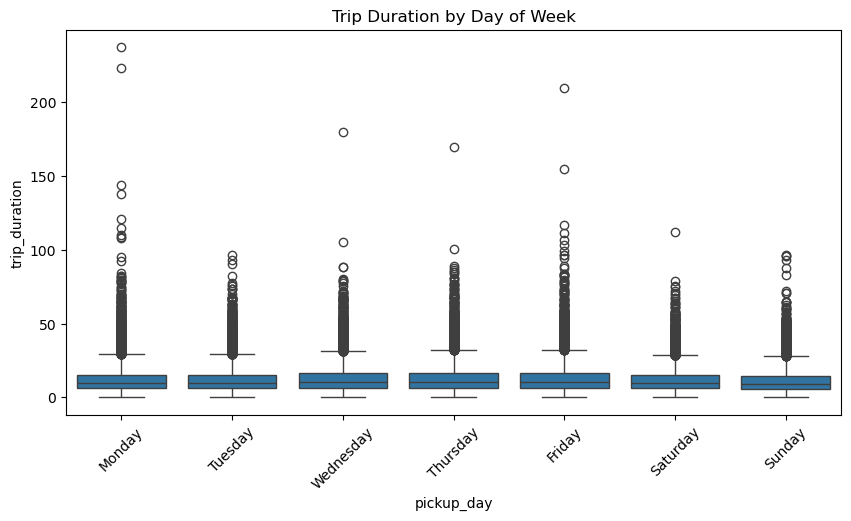

In [18]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10,5))
sns.boxplot(x='pickup_day', y='trip_duration', data=df, order=day_order)
plt.title('Trip Duration by Day of Week')
plt.xticks(rotation=45)
plt.show()

Trip duration remains relatively consistent across days of the week, with only minor variation observed. Weekdays show slightly higher median durations compared to weekends, which may reflect increased traffic during workdays. However, the overall differences are modest, suggesting that day of the week is not a major driver of trip duration.

### Passenger Count Analysis

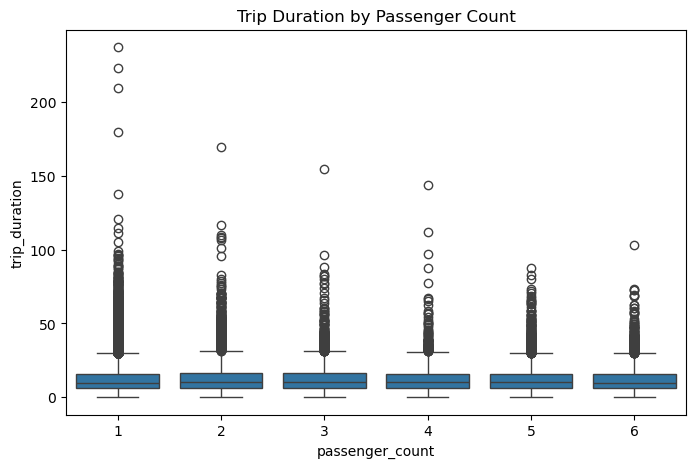

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x='passenger_count', y='trip_duration', data=df)
plt.title('Trip Duration by Passenger Count')
plt.show()

Trip duration appears to be relatively consistent across different passenger counts, with median values remaining within a similar range. While there is slight variation for larger groups, the distributions largely overlap, indicating that passenger count does not have a strong influence on trip duration.

### Correlation Analysis

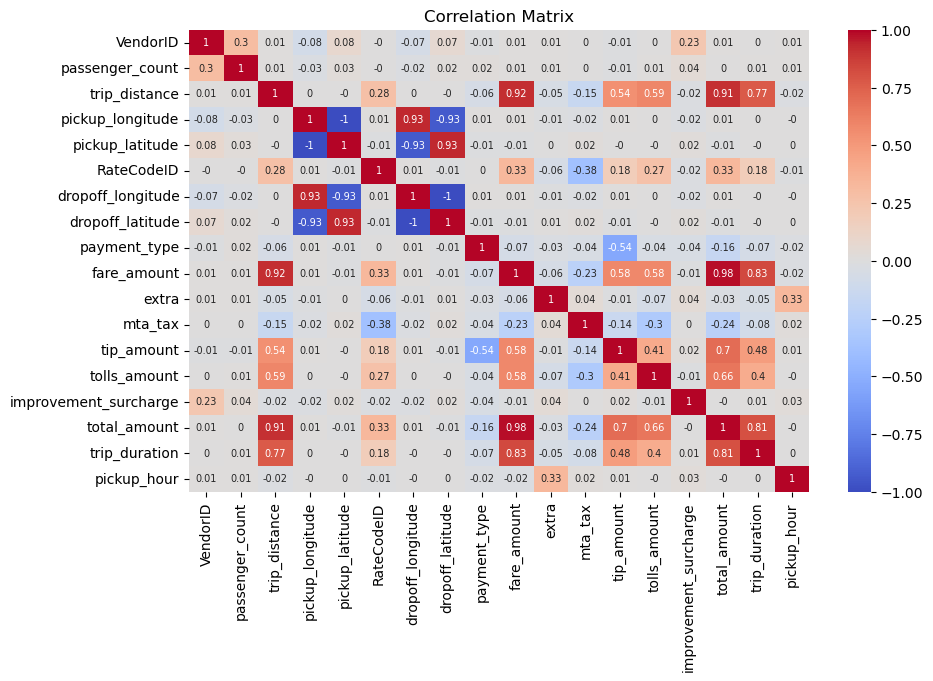

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True).round(2),
    annot=True,
    cmap='coolwarm',
    annot_kws={"size": 7}
)
plt.title('Correlation Matrix')
plt.show()

The correlation matrix shows that trip distance has a strong positive relationship with trip duration, confirming it as a key driver of trip length. Fare-related variables, such as total amount and fare amount, also show strong correlations with trip duration, likely due to their dependence on trip distance. Other variables, including passenger count and pickup hour, exhibit weak correlations, suggesting they have a limited direct impact on trip duration.

## Key Insights

- Trip duration is right-skewed, with most trips lasting between approximately 5 and 20 minutes.
- Trip distance is the strongest factor influencing trip duration, showing a clear positive relationship.
- Time of day has a moderate impact, with slightly longer trips observed during peak commuting hours.
- Day of the week shows minimal variation in trip duration.
- Passenger count does not significantly affect trip duration.